In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import glob
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from PIL import Image
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
from tqdm.auto import tqdm

# ============================================================
# SETUP PATH
# ============================================================

WORK_DIR = Path("/content/drive/MyDrive/Computational Imaging/Code")
RETINA_DATASET_PATH = Path("/content/drive/MyDrive/Computational Imaging/Dataset/retinal_data/images")

# Cartella dove salveremo il dataset preprocessato in .pt
PROCESSED_DATASET_DIR = Path("/content/drive/MyDrive/Computational Imaging/Dataset/retina_processed")

# Find IPPy folder
for base in (WORK_DIR, *WORK_DIR.parents):
    if (base / "IPPy").exists():
        sys.path.append(str(base))
        break
else:
    raise FileNotFoundError("Could not find IPPy folder.")

from IPPy import operators, utilities

device = utilities.get_device()
torch.manual_seed(0)

print("Device:", device)
print("Working directory:", WORK_DIR)
print("Retina dataset path:", RETINA_DATASET_PATH)
print("Processed dataset path:", PROCESSED_DATASET_DIR)

Device: cpu
Working directory: /content/drive/MyDrive/Computational Imaging/Code
Retina dataset path: /content/drive/MyDrive/Computational Imaging/Dataset/retinal_data/images
Processed dataset path: /content/drive/MyDrive/Computational Imaging/Dataset/retina_processed


In [3]:
# ============================================================
# CLEAN DATASET
# ============================================================

class RetinaDataset(Dataset):
    def __init__(self, data_path, data_shape=256, max_images=4000):
        super().__init__()

        self.fname_list = sorted(glob.glob(f"{data_path}/**/*.png", recursive=True))

        if max_images is not None:
            self.fname_list = self.fname_list[:max_images]

        self.transform = transforms.Compose([
            transforms.Resize((data_shape, data_shape)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.fname_list)

    def __getitem__(self, idx):
        img_path = self.fname_list[idx]
        x = Image.open(img_path).convert("L")
        x = self.transform(x)
        return x

In [4]:
# ============================================================
# BUILD DATASET AND SPLITS
# ============================================================

full_dataset = RetinaDataset(
    data_path=str(RETINA_DATASET_PATH),
    data_shape=256,
    max_images=4000,
)

print("Total images:", len(full_dataset))

train_size = int(0.70 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(0),
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

Total images: 4000
Train images: 2800
Validation images: 600
Test images: 600


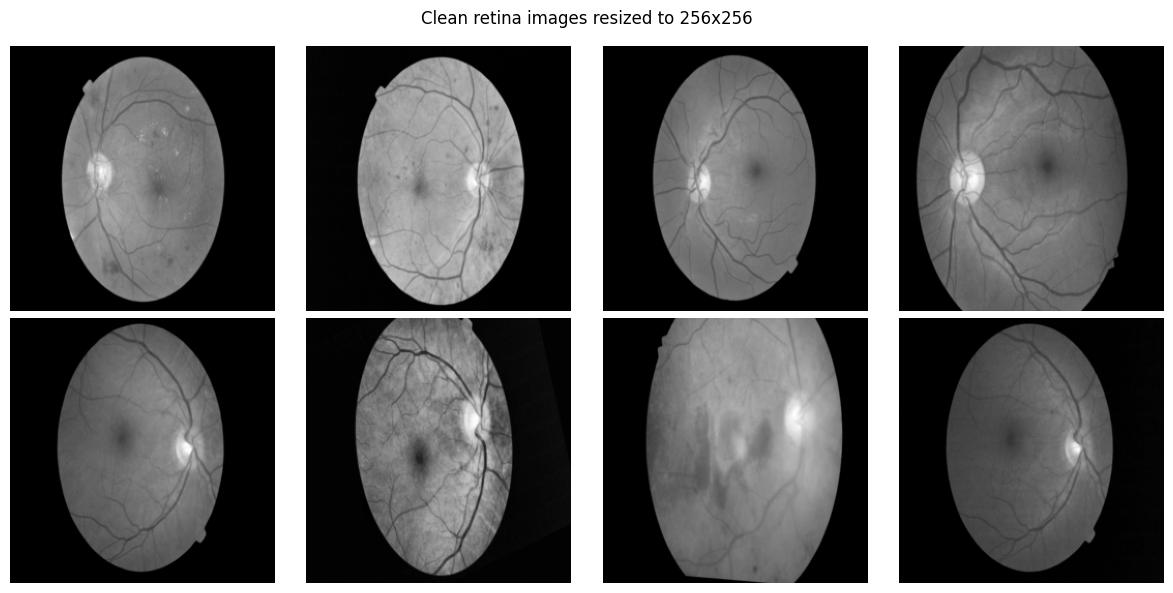

In [5]:
# ============================================================
# SHOW CLEAN EXAMPLES
# ============================================================

def show_batch(batch, title, ncols=4):
    batch = batch.detach().cpu()
    n = min(len(batch), 8)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
    axes = axes.reshape(-1) if hasattr(axes, "reshape") else [axes]

    for ax, image in zip(axes, batch[:n]):
        ax.imshow(image.squeeze(), cmap="gray")
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


x_batch = next(iter(train_loader))
show_batch(x_batch, "Clean retina images resized to 256x256")

In [6]:
# ============================================================
# DEFINE MOTION BLUR OPERATOR
# ============================================================

K = operators.Blurring(
    img_shape=(256, 256),
    kernel_type="motion",
    kernel_size=9,
    motion_angle=45,
)

NOISE_LEVELS = [0.005, 0.01, 0.05, 0.1]

print("Motion blur operator created.")
print("Kernel size:", 9)
print("Motion angle:", 45)
print("Noise levels:", NOISE_LEVELS)

Motion blur operator created.
Kernel size: 9
Motion angle: 45
Noise levels: [0.005, 0.01, 0.05, 0.1]


In [7]:
# ============================================================
# FUNCTION TO DEGRADE IMAGES
# ============================================================

def degrade_images(x, K, noise_level):
    with torch.no_grad():
        y_blur = K(x)
        y_delta = y_blur + utilities.gaussian_noise(
            y_blur,
            noise_level=noise_level,
        )

    return y_delta

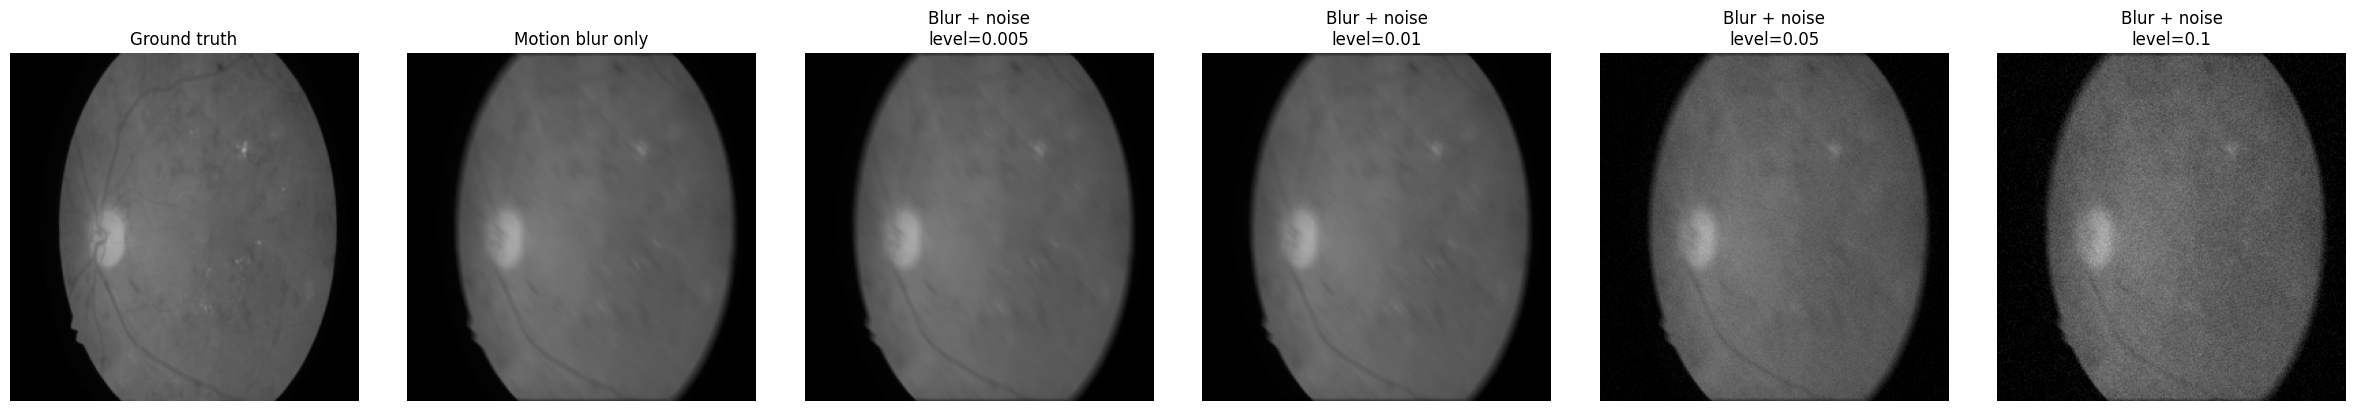

x_true shape: (1, 1, 256, 256)
y_delta shape: (1, 1, 256, 256)


In [8]:
# ============================================================
# VISUALIZE DEGRADATION AT DIFFERENT NOISE LEVELS
# ============================================================

x_true = next(iter(test_loader))[0:1].to(device)

fig, axes = plt.subplots(
    1,
    2 + len(NOISE_LEVELS),
    figsize=(4 * (2 + len(NOISE_LEVELS)), 4),
)

axes[0].imshow(x_true.cpu().squeeze(), cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Ground truth")
axes[0].axis("off")

with torch.no_grad():
    y_blur = K(x_true)

axes[1].imshow(y_blur.cpu().squeeze(), cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Motion blur only")
axes[1].axis("off")

for i, noise_level in enumerate(NOISE_LEVELS, start=2):
    y_delta = degrade_images(x_true, K, noise_level)

    axes[i].imshow(y_delta.cpu().squeeze().clamp(0, 1), cmap="gray", vmin=0, vmax=1)
    axes[i].set_title(f"Blur + noise\nlevel={noise_level}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

print("x_true shape:", tuple(x_true.shape))
print("y_delta shape:", tuple(y_delta.shape))

In [9]:
# ============================================================
# SAVE DEGRADED DATASET AS .pt FILES
# ============================================================

def noise_file_name(noise_level):
    return f"noise_{str(noise_level).replace('.', '_')}.pt"


def get_source_path(split_dataset, idx):
    if hasattr(split_dataset, "indices") and hasattr(split_dataset.dataset, "fname_list"):
        original_idx = split_dataset.indices[idx]
        return split_dataset.dataset.fname_list[original_idx]
    return str(idx)


def tensorize_split(split_dataset, split_name, K, noise_level):
    clean_list = []
    degraded_list = []
    source_paths = []

    for idx in tqdm(range(len(split_dataset)), desc=f"{split_name} | noise={noise_level}"):
        x = split_dataset[idx]

        if isinstance(x, tuple):
            x = x[0]

        x = x.unsqueeze(0).to(device)

        with torch.no_grad():
            y_blur = K(x)
            y_delta = y_blur + utilities.gaussian_noise(
                y_blur,
                noise_level=noise_level,
            )

        clean_list.append(
            x.squeeze(0).detach().cpu().clamp(0.0, 1.0)
        )

        degraded_list.append(
            y_delta.squeeze(0).detach().cpu().clamp(0.0, 1.0)
        )

        source_paths.append(get_source_path(split_dataset, idx))

    clean_tensor = torch.stack(clean_list, dim=0)
    degraded_tensor = torch.stack(degraded_list, dim=0)

    payload = {
        "clean": clean_tensor,
        "degraded": degraded_tensor,
        "source_paths": source_paths,
        "metadata": {
            "split": split_name,
            "noise_level": noise_level,
            "motion_angle": 45,
            "kernel_size": 9,
            "image_size": 256,
        },
    }

    return payload


def save_split_as_pt(split_dataset, split_name, K, noise_levels, output_root):
    split_dir = output_root / split_name
    split_dir.mkdir(parents=True, exist_ok=True)

    for noise_level in noise_levels:
        payload = tensorize_split(
            split_dataset=split_dataset,
            split_name=split_name,
            K=K,
            noise_level=noise_level,
        )

        output_path = split_dir / noise_file_name(noise_level)
        torch.save(payload, output_path)

        print("Saved:", output_path)
        print("Clean tensor shape:", tuple(payload["clean"].shape))
        print("Degraded tensor shape:", tuple(payload["degraded"].shape))

In [10]:
# ============================================================
# GENERATE AND SAVE TRAIN / VALIDATION / TEST
# ============================================================

PROCESSED_DATASET_DIR.mkdir(parents=True, exist_ok=True)

torch.manual_seed(0)

save_split_as_pt(
    split_dataset=train_dataset,
    split_name="train",
    K=K,
    noise_levels=NOISE_LEVELS,
    output_root=PROCESSED_DATASET_DIR,
)

save_split_as_pt(
    split_dataset=val_dataset,
    split_name="validation",
    K=K,
    noise_levels=NOISE_LEVELS,
    output_root=PROCESSED_DATASET_DIR,
)

save_split_as_pt(
    split_dataset=test_dataset,
    split_name="test",
    K=K,
    noise_levels=NOISE_LEVELS,
    output_root=PROCESSED_DATASET_DIR,
)

print("Done. Processed dataset saved in:", PROCESSED_DATASET_DIR)

train | noise=0.005:   0%|          | 0/2800 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/Computational Imaging/Dataset/retina_processed/train/noise_0_005.pt
Clean tensor shape: (2800, 1, 256, 256)
Degraded tensor shape: (2800, 1, 256, 256)


train | noise=0.01:   0%|          | 0/2800 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/Computational Imaging/Dataset/retina_processed/train/noise_0_01.pt
Clean tensor shape: (2800, 1, 256, 256)
Degraded tensor shape: (2800, 1, 256, 256)


train | noise=0.05:   0%|          | 0/2800 [00:00<?, ?it/s]

...

Saved: /content/drive/MyDrive/Computational Imaging/Dataset/retina_processed/test/noise_0_01.pt
Clean tensor shape: (600, 1, 256, 256)
Degraded tensor shape: (600, 1, 256, 256)


test | noise=0.05:   0%|          | 0/600 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/Computational Imaging/Dataset/retina_processed/test/noise_0_05.pt
Clean tensor shape: (600, 1, 256, 256)
Degraded tensor shape: (600, 1, 256, 256)


test | noise=0.1:   0%|          | 0/600 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/Computational Imaging/Dataset/retina_processed/test/noise_0_1.pt
Clean tensor shape: (600, 1, 256, 256)
Degraded tensor shape: (600, 1, 256, 256)
Done. Processed dataset saved in: /content/drive/MyDrive/Computational Imaging/Dataset/retina_processed


In [11]:
# ============================================================
# DATASET FOR .pt DEGRADED PAIRS
# ============================================================

class RetinaPTDataset(Dataset):
    def __init__(self, pt_path):
        super().__init__()

        payload = torch.load(pt_path, map_location="cpu")

        self.clean = payload["clean"]
        self.degraded = payload["degraded"]
        self.source_paths = payload["source_paths"]
        self.metadata = payload["metadata"]

    def __len__(self):
        return self.clean.shape[0]

    def __getitem__(self, idx):
        y = self.degraded[idx]
        x = self.clean[idx]
        return y, x

In [12]:
# ============================================================
# CREATE DATALOADERS FROM .pt FILES
# ============================================================

noise_level = 0.01

train_pt = PROCESSED_DATASET_DIR / "train" / noise_file_name(noise_level)
val_pt = PROCESSED_DATASET_DIR / "validation" / noise_file_name(noise_level)
test_pt = PROCESSED_DATASET_DIR / "test" / noise_file_name(noise_level)

train_dataset_pt = RetinaPTDataset(train_pt)
val_dataset_pt = RetinaPTDataset(val_pt)
test_dataset_pt = RetinaPTDataset(test_pt)

train_loader_pt = DataLoader(train_dataset_pt, batch_size=8, shuffle=True)
val_loader_pt = DataLoader(val_dataset_pt, batch_size=8, shuffle=False)
test_loader_pt = DataLoader(test_dataset_pt, batch_size=8, shuffle=False)

print("Loaded noise level:", noise_level)
print("Train samples:", len(train_dataset_pt))
print("Validation samples:", len(val_dataset_pt))
print("Test samples:", len(test_dataset_pt))
print("Metadata:", train_dataset_pt.metadata)

Loaded noise level: 0.01
Train samples: 2800
Validation samples: 600
Test samples: 600
Metadata: {'split': 'train', 'noise_level': 0.01, 'motion_angle': 45, 'kernel_size': 9, 'image_size': 256}


Input degraded batch shape: (8, 1, 256, 256)
Target clean batch shape: (8, 1, 256, 256)


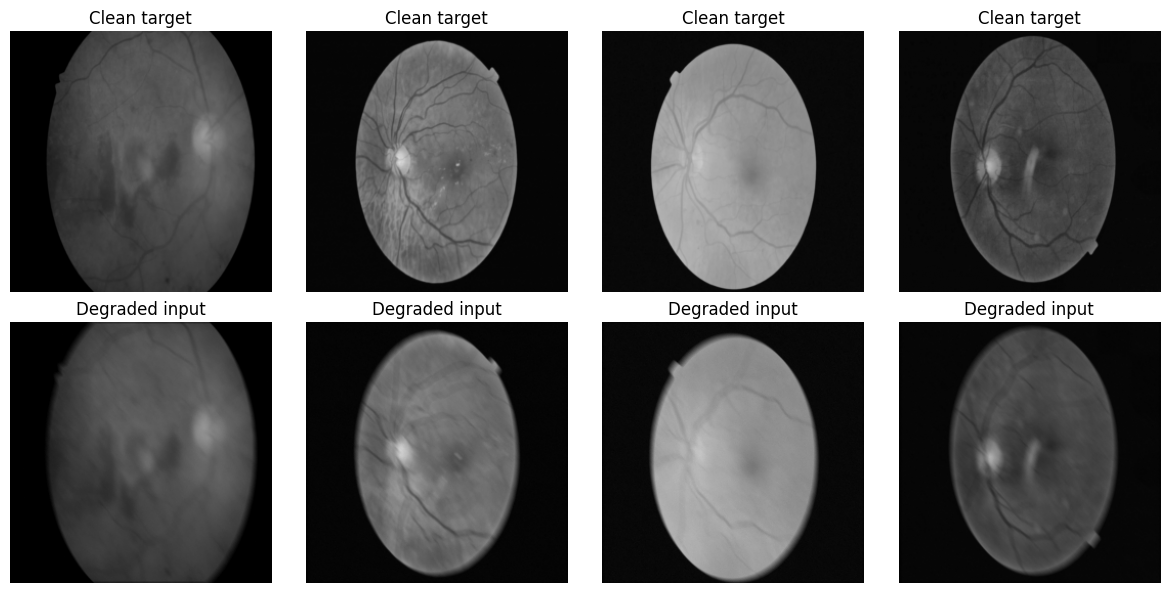

In [13]:
# ============================================================
# VISUALIZE SAVED .pt DEGRADED PAIRS
# ============================================================

y_batch, x_batch = next(iter(train_loader_pt))

print("Input degraded batch shape:", tuple(y_batch.shape))
print("Target clean batch shape:", tuple(x_batch.shape))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(4):
    axes[0, i].imshow(x_batch[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title("Clean target")
    axes[0, i].axis("off")

    axes[1, i].imshow(y_batch[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title("Degraded input")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()